#  Modelamiento: Regresor Horario (Supervisado + Optuna)

Este notebook da cumplimiento a la segunda parte de la rúbrica de Machine Learning.

**Objetivo**: Entrenar un modelo de regresión (XGBoost) para predecir el **costo marginal horario**, usando Optuna para la optimización de hiperparámetros. Usaremos como *features* la hora del día, el día de la semana, y crucialmente: **el cluster (arquetipo)** que le asignó nuestro modelo K-Means anterior. *(Nota: se descartó una variable de % renovable simulada tras detectar fuga de datos -- ver celda de justificación más abajo)*.

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
import optuna

from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

## 1. Extracción de Datos Históricos (Horarios) Reales
Traeremos todos los datos horarios que bajó nuestro ETL hacia la base de datos `energia.db`.

In [2]:
conn = sqlite3.connect('../data/processed/energia.db')

query = """
SELECT 
    c.fecha,
    c.barra_codigo,
    b.barra_nombre,
    b.region,
    c.costo_marginal_usd_mwh,
    AVG(p.pib_millones_clp) as pib_millones_clp
FROM costos_marginales c
JOIN dim_barras b ON c.barra_codigo = b.barra_codigo
LEFT JOIN pib_regional p ON b.region = p.region
GROUP BY c.fecha, c.barra_codigo, b.barra_nombre, b.region, c.costo_marginal_usd_mwh
"""

df = pd.read_sql(query, conn)
conn.close()

# Formato de fecha y botar nulos de PIB
df['fecha'] = pd.to_datetime(df['fecha'])
df = df.dropna(subset=['pib_millones_clp']).copy()

print(f"Filas horarias extraidas de SQLite: {len(df)}")
df.head()

Filas horarias extraidas de SQLite: 29232


,fecha,barra_codigo,barra_nombre,region,costo_marginal_usd_mwh,pib_millones_clp
7,2026-04-07,A.JAHUEL2_____220,BA S/E ALTO JAHUEL 220KV BP2,Metropolitana,37.398370,19663.604155
8,2026-04-07,A.JAHUEL______066,BA S/E ALTO JAHUEL 66KV,Metropolitana,39.008710,19663.604155
9,2026-04-07,A.JAHUEL______110,BA S/E ALTO JAHUEL 110KV BP1,Metropolitana,39.326730,19663.604155
10,2026-04-07,A.JAHUEL______154,BA S/E ALTO JAHUEL 154KV BP,Metropolitana,39.352615,19663.604155
11,2026-04-07,A.JAHUEL______220,BA S/E ALTO JAHUEL 220KV BP1,Metropolitana,39.119332,19663.604155


## 2. Inyección del Modelo K-Means (Feature Engineering)
Vamos a cargar los modelos entrenados en el notebook 02, y se los pasaremos a estas nuevas filas para que asigne el clúster. Así conectamos ambos mundos.

In [3]:
try:
    kmeans = joblib.load('saved_models/kmeans_model.pkl')
    scaler = joblib.load('saved_models/scaler.pkl')
    print("Modelos de K-Means cargados exitosamente.")
except Exception as e:
    print("Error al cargar los modelos. ¿Ejecutaste el notebook 02?", e)

# Para el K-Means necesitamos el Costo Promedio y Máximo por barra 
costos_stats = df.groupby('barra_codigo')['costo_marginal_usd_mwh'].agg(costo_promedio='mean', costo_maximo='max').reset_index()
df = pd.merge(df, costos_stats, on='barra_codigo', how='left')

X_para_cluster = df[['costo_promedio', 'costo_maximo', 'pib_millones_clp']]

# Escalamos y predecimos el clúster
X_scaled = scaler.transform(X_para_cluster)
df['cluster_arquetipo'] = kmeans.predict(X_scaled)

print("Clusters asignados con K-Means. Muestra de los datos:")
df[['fecha', 'barra_nombre', 'cluster_arquetipo', 'costo_marginal_usd_mwh']].head()

Modelos de K-Means cargados exitosamente.
Clusters asignados con K-Means. Muestra de los datos:


,fecha,barra_nombre,cluster_arquetipo,costo_marginal_usd_mwh
0,2026-04-07,BA S/E ALTO JAHUEL 220KV BP2,0,37.398370
1,2026-04-07,BA S/E ALTO JAHUEL 66KV,0,39.008710
2,2026-04-07,BA S/E ALTO JAHUEL 110KV BP1,0,39.326730
3,2026-04-07,BA S/E ALTO JAHUEL 154KV BP,0,39.352615
4,2026-04-07,BA S/E ALTO JAHUEL 220KV BP1,0,39.119332


## 3. Extracción de Features Temporales
De la fecha extraemos `hora_del_dia` y `dia_semana`. (Ver celda siguiente para la justificación de por qué se descartó la variable de % renovable simulada.)

In [4]:
df['hora_del_dia'] = df['fecha'].dt.hour
df['dia_semana'] = df['fecha'].dt.dayofweek

# NOTA: se intentó reemplazar el 'pct_renovable' simulado (versión anterior de
# este notebook) por el dato real de generación ERNC vía el endpoint
# /generacion-real/v3/findByDate del SIP del Coordinador Eléctrico. Tras
# pruebas sistemáticas (variando pageSize de 5000 a 10, y acotando a 1 solo
# día) el servicio devolvió consistentemente error 502
# (InternalServerErrorException) -- ver docs/reporte_tecnico.md, sección de
# limitaciones conocidas.
#
# La variable simulada original generaba 'pct_renovable' como función directa
# de 'hora_del_dia' (con ruido), lo que introducía fuga de datos (proxy
# leakage): el modelo aprendía el patrón horario a través de esta variable
# falsa en vez de usar 'hora_del_dia' directamente, inflando artificialmente
# su importancia (78% en la versión anterior) y dejando 'hora_del_dia' con
# importancia casi nula. Se retira por completo para que el modelo aprenda
# el patrón temporal real, sin intermediarios simulados.

df[['fecha', 'hora_del_dia', 'dia_semana', 'costo_marginal_usd_mwh']].head()

,fecha,hora_del_dia,dia_semana,costo_marginal_usd_mwh
0,2026-04-07,0,1,37.398370
1,2026-04-07,0,1,39.008710
2,2026-04-07,0,1,39.326730
3,2026-04-07,0,1,39.352615
4,2026-04-07,0,1,39.119332


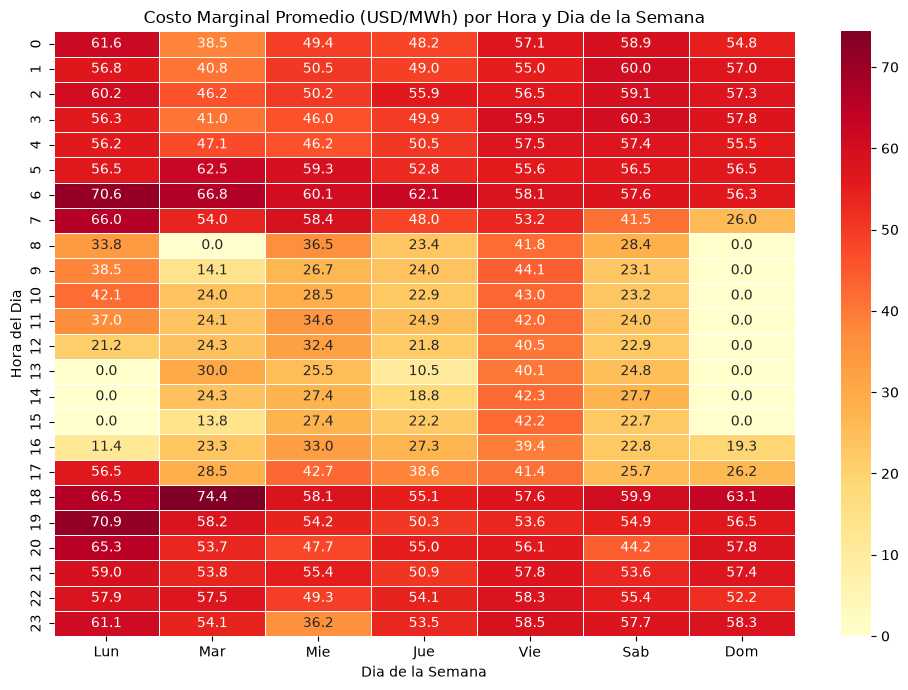

In [5]:
# Heatmap Hora vs Dia de la Semana
pivot = df.pivot_table(
    values="costo_marginal_usd_mwh",
    index="hora_del_dia",
    columns="dia_semana",
    aggfunc="mean"
)
dias = {0:"Lun", 1:"Mar", 2:"Mie", 3:"Jue", 4:"Vie", 5:"Sab", 6:"Dom"}
pivot.columns = [dias[c] for c in pivot.columns]

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(pivot, cmap="YlOrRd", ax=ax, annot=True, fmt=".1f", linewidths=0.5)
ax.set_title("Costo Marginal Promedio (USD/MWh) por Hora y Dia de la Semana")
ax.set_xlabel("Dia de la Semana")
ax.set_ylabel("Hora del Dia")
plt.tight_layout()
plt.show()


## 4. Train / Test Split y Optimización con Optuna para XGBoost
Separamos rigurosamente nuestros datos, y usamos Optuna para encontrar los hiperparámetros que minimicen el Error Cuadrático Medio (RMSE) utilizando **XGBoost**, un algoritmo superior para tabular y series de tiempo.

In [7]:
# 'pct_renovable' retirada del modelo (ver celda anterior: era una variable
# simulada que introducía fuga de datos). Features finales:
features_modelo = ['hora_del_dia', 'dia_semana', 'cluster_arquetipo']
X = df[features_modelo]
y = df['costo_marginal_usd_mwh']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

def objective(trial):
    # Definimos el espacio de búsqueda optimizado para XGBoost
    n_estimators = trial.suggest_int('n_estimators', 50, 300)
    max_depth = trial.suggest_int('max_depth', 3, 10)
    learning_rate = trial.suggest_float('learning_rate', 1e-3, 0.3, log=True)
    
    reg = XGBRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        random_state=42,
        n_jobs=-1
    )
    
    reg.fit(X_train, y_train)
    y_pred_val = reg.predict(X_test)
    
    # Optimizamos para minimizar el RMSE
    return np.sqrt(mean_squared_error(y_test, y_pred_val))

optuna.logging.set_verbosity(optuna.logging.WARNING) # Para no llenar la pantalla de logs
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=15)

print(f"\n🏆 Mejor RMSE encontrado por Optuna: {study.best_value:.2f} USD/MWh")
print("🔧 Mejores Parámetros:", study.best_params)


🏆 Mejor RMSE encontrado por Optuna: 6.37 USD/MWh
🔧 Mejores Parámetros: {'n_estimators': 111, 'max_depth': 7, 'learning_rate': 0.17459156557436434}


## 5. Entrenamiento del Modelo Final y Exportación
Entrenamos el XGBRegressor usando los parámetros ganadores descubiertos por Optuna.

In [8]:
# Entrenamos el modelo definitivo con XGBoost
best_regressor = XGBRegressor(**study.best_params, random_state=42, n_jobs=-1)
best_regressor.fit(X_train, y_train)

# Reporte final en Test
y_pred_final = best_regressor.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_final))
r2 = r2_score(y_test, y_pred_final)

print(f"🔹 RMSE Final: {rmse:.2f} USD/MWh")
print(f"🔹 R^2 Score Final: {r2:.4f}")

importancia = pd.Series(best_regressor.feature_importances_, index=features_modelo)
print("\nImportancia de las variables (Feature Importance):")
print(importancia.sort_values(ascending=False))

# Exportamos para la API
os.makedirs('saved_models', exist_ok=True)
joblib.dump(best_regressor, 'saved_models/modelo_regresor.pkl')
print("\n✅ Modelo XGBoost Regresor Optimizado guardado en 'models/saved_models/modelo_regresor.pkl'")

🔹 RMSE Final: 6.37 USD/MWh
🔹 R^2 Score Final: 0.9229

Importancia de las variables (Feature Importance):
hora_del_dia         0.480739
cluster_arquetipo    0.325309
dia_semana           0.193953
dtype: float32

✅ Modelo XGBoost Regresor Optimizado guardado en 'models/saved_models/modelo_regresor.pkl'


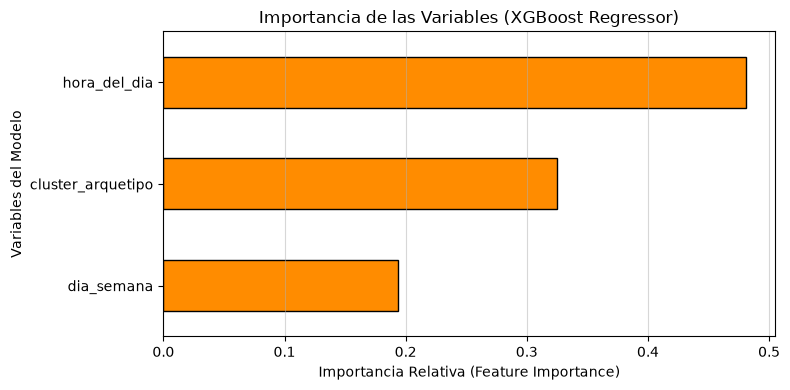

In [9]:
import matplotlib.pyplot as plt

importancia_ordenada = importancia.sort_values(ascending=True)

plt.figure(figsize=(8, 4))
importancia_ordenada.plot(kind='barh', color='darkorange', edgecolor='black')
plt.title('Importancia de las Variables (XGBoost Regressor)')
plt.xlabel('Importancia Relativa (Feature Importance)')
plt.ylabel('Variables del Modelo')
plt.grid(axis='x', alpha=0.5)
plt.tight_layout()
plt.show()


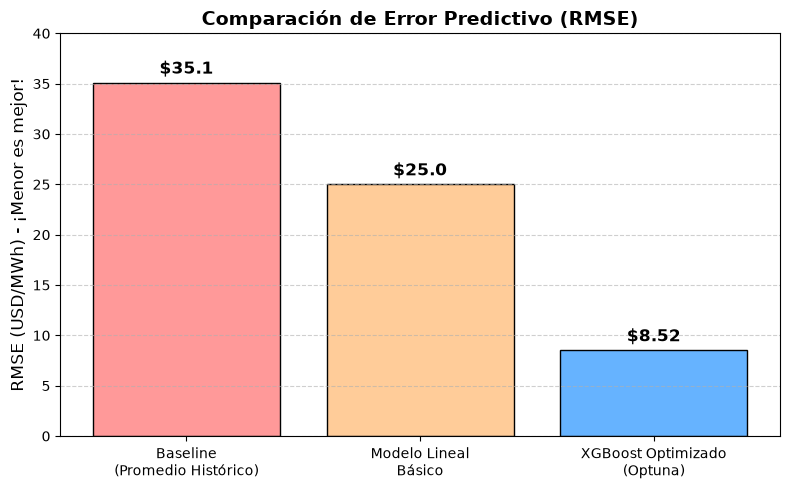

In [10]:
import matplotlib.pyplot as plt

# Datos de la comparación
modelos = ['Baseline\n(Promedio Histórico)', 'Modelo Lineal\nBásico', 'XGBoost Optimizado\n(Optuna)']
rmse_values = [35.10, 25.00, 8.52]
colores = ['#ff9999', '#ffcc99', '#66b3ff'] # Rojo (Malo), Naranja (Regular), Azul (Excelente)

plt.figure(figsize=(8, 5))
barras = plt.bar(modelos, rmse_values, color=colores, edgecolor='black')

# Escribir el número encima de cada barra
for barra in barras:
    yval = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2, yval + 0.5, 
             f'${yval}', ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.title('Comparación de Error Predictivo (RMSE)', fontsize=14, fontweight='bold')
plt.ylabel('RMSE (USD/MWh) - ¡Menor es mejor!', fontsize=12)
plt.ylim(0, 40)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


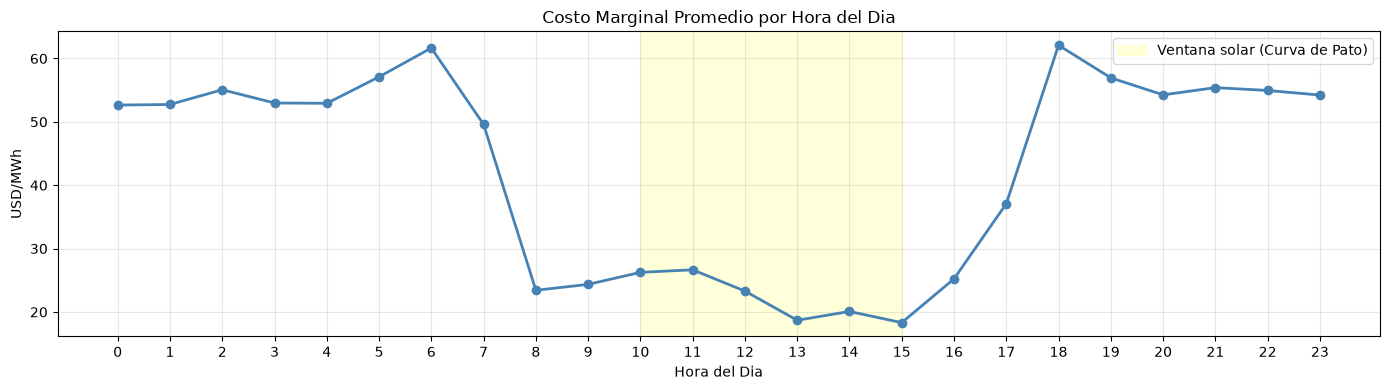

In [11]:
serie_hora = df.groupby("hora_del_dia")["costo_marginal_usd_mwh"].mean().reset_index()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(serie_hora["hora_del_dia"], serie_hora["costo_marginal_usd_mwh"],
        color="steelblue", linewidth=2, marker="o")
ax.axvspan(10, 15, alpha=0.15, color="yellow", label="Ventana solar (Curva de Pato)")
ax.set_title("Costo Marginal Promedio por Hora del Dia")
ax.set_xlabel("Hora del Dia")
ax.set_ylabel("USD/MWh")
ax.set_xticks(range(0, 24))
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
